## 1. Introduction

The goal of this project is to predict hourly bike rental demand using supervised machine learning regression models. The dataset contains environmental, seasonal, and temporal variables collected from a bike-sharing system, including weather conditions, temperature, humidity, season, and hour of the day.

This project includes exploratory data analysis (EDA), feature engineering, preprocessing, model training, hyperparameter tuning, and final evaluation.

Three regression models of increasing complexity are used throughout the assignment:

1. Linear Regression as a simple and interpretable baseline model.
2. Random Forest Regressor as an ensemble model capable of capturing nonlinear relationships.
3. Gradient Boosting Regressor as a more advanced boosting-based ensemble method.

The models are evaluated using Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² Score. The final objective is to compare the performance of all the models and select the one that generalizes best to unseen data.

## 2. Data Loading and Initial Exploration

In this section, the dataset is loaded and inspected to better understand its structure, variable types, and characteristics before preprocessing and modeling.

In [107]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [108]:
df = pd.read_csv('/kaggle/input/datasets/zaidjumean/bike-sharing/hour.csv')

In [109]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


The dataset was succesfully loaded from `hour.csv`. It contains 17,379 hourly records and includes temporal, seasonal, weather-related, and rental-count variables.

From the initial inspection, it shows that there are no missing values in the main columns. The target variable is `cnt`, which represents the total number of rented bikes per hour. Since `cnt` is a continuous numerical variable, the assignment will be treated as a Regression problem.

The columns `casual` and `registered` together form the target variable `cnt`. This means the model could predict `cnt` perfectly by adding the two variables. Therefore, they should not be used as input features during model training, because this would cause data leakage. This is considered target leakage because the model would have access to information that directly determines the target value.

## 3. Target Variable Analysis

In this section, the target variable `cnt` is analyzed to better understand its distribution and suitability for regression modeling.

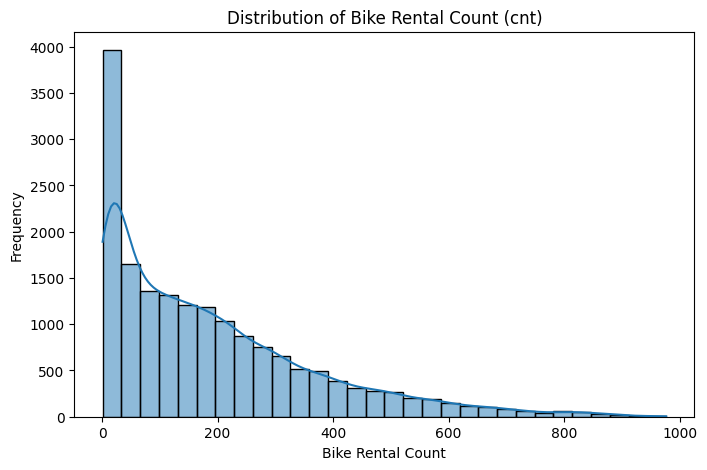

In [110]:
plt.figure(figsize=(8,5))

sns.histplot(df['cnt'], bins=30, kde=True)

plt.title('Distribution of Bike Rental Count (cnt)')
plt.xlabel('Bike Rental Count')
plt.ylabel('Frequency')

plt.show()

The target variable `cnt` shows a slightly right-skewed distribution, meaning lower and medium rental counts occur more frequently than very high rental counts. Since `cnt` is a continuous numerical variable, regression models can be used to predict bike rental counts.

## 4. Data Cleaning and Missing Values

Before training the models, the dataset was checked for missing values, duplicated rows, and unnecessary features. No missing values were found in the dataset,so no imputations were applied.

The columns `instant`, `dteday`, `casual`, and `registered` were removed before modeling:
- `instant` is only a record identifier
- `dteday` contains raw date information that is not directly useful 
- `casual` and `registered` create target leakage because together they form the target variable `cnt`

In [111]:
print(df.isnull().sum())

print("Duplicated rows:", df.duplicated().sum())

df = df.drop(columns=['instant', 'dteday', 'casual', 'registered'], errors = 'ignore')

print(df.columns)

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Duplicated rows: 0
Index(['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')


Two duplicated rows were found in the dataset, but this will not significantly affect the model preformance since the number is very small compared to the size of the dataset 

## 5. Feature Engineering

Feature engineering was performed to improve the quality of the input data before training the models. Cyclical transformations were applied to time-related variables such as hours and weekday. Other preprocessing steps include one-hot encoding and feature scaling, which were later handled using the preprocessing pipeline so that the transfomations were fitted only on the training data before being applied to the validation and test sets. Leaky features were also removed to avoid any data leakage.


In [112]:
# Create cyclical features for hour
df['hr_sin'] = np.sin(2 * np.pi * df['hr'] / 24)
df['hr_cos'] = np.cos(2 * np.pi * df['hr'] / 24)

# Create cyclical features for weekday
df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

# Define target variable
y = df['cnt']

# Define input features
X = df.drop(columns=['cnt'])

# Display first rows
X.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,hr_sin,hr_cos,weekday_sin,weekday_cos
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,0.000000,1.000000,-0.781831,0.62349
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,0.258819,0.965926,-0.781831,0.62349
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,0.500000,0.866025,-0.781831,0.62349
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,0.707107,0.707107,-0.781831,0.62349
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0.866025,0.500000,-0.781831,0.62349


## 6. Data Splitting

The dataset was split into training, validation, and test sets before scaling and model training. This helps evaluate the model performance on unseen data and reduces the risk of data leakage.

In [113]:
# Split into training and temporary sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42
)

# Split temporary set into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

# Display dataset sizes
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (10427, 16)
Validation set: (3476, 16)
Test set: (3476, 16)


The dataset was first split into a 60% training set and a 40% temporary set. The temporary set was then split equally to create the validation and test sets. This created a final distribution of 60% training data, 20% validation data, and 20% test data.

## 7. Feature Scaling and Encoding

Before training the models, numerical and categorical features were separated during processing. Numerical variables were standardized using `StandardScaler`, and categorical variables were transformed using one-hot encoding.

Scaling helps put numerical variables on a similar range, while one-hot encoding converts categorical variables into a format that machine learning models can use correctly.

In [114]:
# Numerical columns to scale
numerical_cols = ['temp', 'atemp', 'hum', 'windspeed']

# Categorical columns to encode
categorical_cols = ['season', 'mnth', 'weathersit']

# Create preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

## 8. Baseline Model – Linear Regression

Linear Regression was used as the baseline model because it is simple, interpretable, and commonly used for regression tasks. The results from this model will later be compared with more advanced models in this assignment

In [115]:
# Create Linear Regression pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train model
lr_pipeline.fit(X_train, y_train)

# Validation predictions
lr_preds = lr_pipeline.predict(X_val)

# Evaluation metrics
lr_mse = mean_squared_error(y_val, lr_preds)
lr_mae = mean_absolute_error(y_val, lr_preds)
lr_r2 = r2_score(y_val, lr_preds)

# Print results
print("Linear Regression Results")
print("MSE:", lr_mse)
print("MAE:", lr_mae)
print("R²:", lr_r2)

Linear Regression Results
MSE: 15614.12827228421
MAE: 91.95927193870547
R²: 0.5195693167625699


The Linear Regression model shows an MSE of 15614.12, an MAE of 91.96, and an R² score of 0.51. This means the model was able to explain around 51% of the variation in bike rental counts. While the model could capture some general patterns in the data, the values shows that there is still room for improvement. 

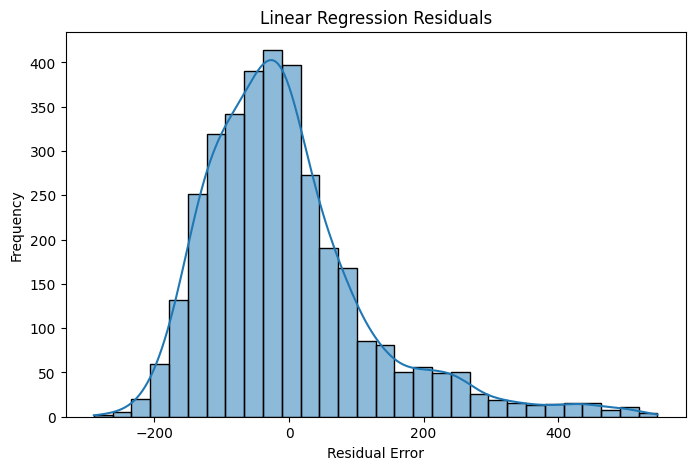

In [116]:
# Residuals
residuals = y_val - lr_preds

# Residual plot
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True)

plt.title("Linear Regression Residuals")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")

plt.show()

The residual distribution is closely centered around zero, although there is still some spread in the errors. This suggests that the Linear Regression model may have have high bias and low variance, since it is simple and may underfit more complex patterns in the dataset

## 9. Random forrest

The Random Forest Regressor was used because it can capture more complex and non-linear relationships in the data compared to Linear Regression. Since it combines predictions from multiple decision trees, it is able to improve prediction accuracy and reduce overfitting

In [117]:
# Create Random Forest pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

# Train model
rf_pipeline.fit(X_train, y_train)

# Validation predictions
rf_preds = rf_pipeline.predict(X_val)

# Evaluation metrics
rf_mse = mean_squared_error(y_val, rf_preds)
rf_mae = mean_absolute_error(y_val, rf_preds)
rf_r2 = r2_score(y_val, rf_preds)

# Print results
print("Random Forest Results")
print("MSE:", rf_mse)
print("MAE:", rf_mae)
print("R²:", rf_r2)

Random Forest Results
MSE: 1815.8670832296782
MAE: 25.958391494054467
R²: 0.9441276356738442


The Random Forest model performed better than the Linear Regression model across all the evaluation metrics. The MSE decreased from 15614.12 to 1815.87, while the MAE decreased from 91.96 to 25.96. In addition, the R² score increased from 0.51 to 0.94, meaning the Random Forest model was able to explain around 94% of the variation in bike rental counts. These results suggest that Random Forest was better at capturing the more complex and non-linear relationships that were present in the dataset.

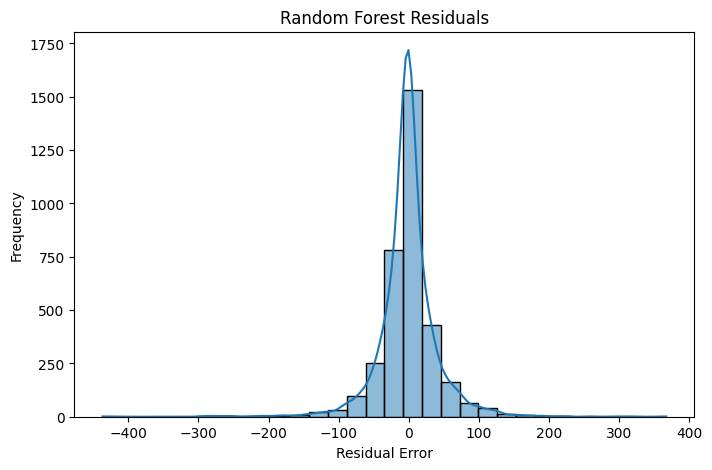

In [118]:
# Residuals
rf_residuals = y_val - rf_preds

# Residual plot
plt.figure(figsize=(8,5))
sns.histplot(rf_residuals, bins=30, kde=True)

plt.title("Random Forest Residuals")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")

plt.show()

The residual distribution is centered closer to zero compared to the Linear Regression model, which suggests that the Random Forest model produced more accurate predictions. The spread of errors being smaller also shows that the model was able to capture more complex patterns in the dataset. However, because Random Forest is a more flexible model, it may also have a higher risk of overfitting compared to Linear Regression.

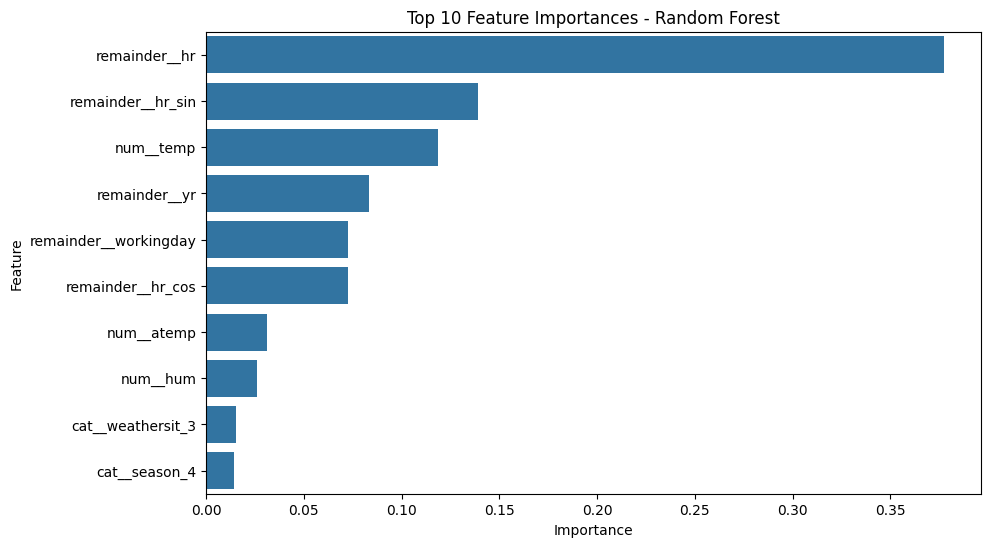

In [119]:
# Feature importance values
feature_names = preprocessor.get_feature_names_out()

importances = rf_pipeline.named_steps['model'].feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort values
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

The feature importance plot shows which variables had the most influence on predicting bike rental demand. Variables related to time, temperature, and working patterns had the higest impact on the model’s predictions. The results show that bike rentals are strongly affected by both weather and time-related factors.

## 10. Gradient Boosting Regressor

Gradient Boosting Regressor was used because it builds models sequentially, which means it allows each new tree to fix the errors of the prevoius one. This leads to a strong prediction performance, especially for complex datasets with non-linear relationships.

In [120]:
# Create Gradient Boosting pipeline
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        random_state=42
    ))
])

# Train model
gb_pipeline.fit(X_train, y_train)

# Validation predictions
gb_preds = gb_pipeline.predict(X_val)

# Evaluation metrics
gb_mse = mean_squared_error(y_val, gb_preds)
gb_mae = mean_absolute_error(y_val, gb_preds)
gb_r2 = r2_score(y_val, gb_preds)

# Print results
print("Gradient Boosting Results")
print("MSE:", gb_mse)
print("MAE:", gb_mae)
print("R²:", gb_r2)

Gradient Boosting Results
MSE: 4506.134680296381
MAE: 46.26665936861738
R²: 0.8613508659937527


The Gradient Boosting model prodcued an MSE of 4506.13, an MAE of 46.27, and an R² score of 0.86. Compared to Linear Regression, the model showed much lower error values, and it was able to capture more complex patterns in the dataset. However, the Random Forest model still preformed better overall with lower error values and a higher R² score.

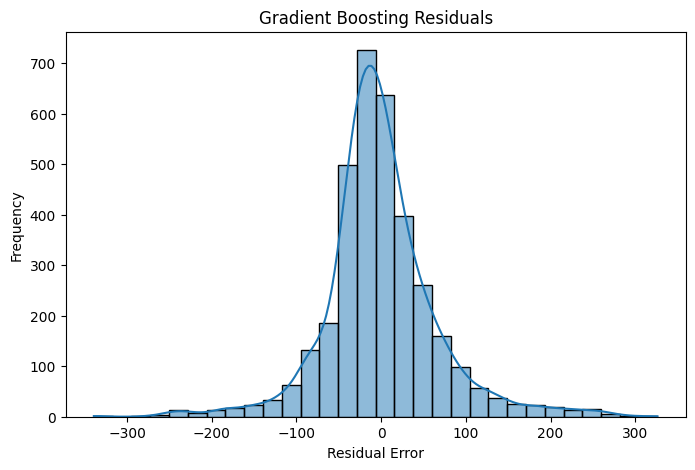

In [121]:
# Residuals
gb_residuals = y_val - gb_preds

# Residual plot
plt.figure(figsize=(8,5))
sns.histplot(gb_residuals, bins=30, kde=True)

plt.title("Gradient Boosting Residuals")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")

plt.show()

The residual distribution is centered closer to zero and shows a smaller error spread compared to the Linear Regression model. This suggests that the Gradient Boosting model was able to fit the data more accurately and reduce prediction errors. Because the model is more complex, it also may have a slightly higher variance and could have fit more noise into that training data comapred to the random forest

## 11. Hyperparameter Tuning

**Random Forrest:**

Hyperparameter tuning was performed to improve the performance of the Random Forest model. RandomizedSearchCV was used to test different parameter combinations and identify the settings that produced the best validation performance.

In [122]:
rf_params = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [2, 5]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    n_iter=3,
    cv=2,
    scoring='r2',
    random_state=42
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
best_rf_preds = best_rf.predict(X_val)

best_rf_mse = mean_squared_error(y_val, best_rf_preds)
best_rf_mae = mean_absolute_error(y_val, best_rf_preds)
best_rf_r2 = r2_score(y_val, best_rf_preds)

print("Best Parameters:", rf_search.best_params_)
print("Tuned Random Forest Results")
print("MSE:", best_rf_mse)
print("MAE:", best_rf_mae)
print("R²:", best_rf_r2)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


KeyboardInterrupt: 

After tuning the Random Forest model, the validation results improved compared to the prevoius Gradient Boosting and Linear Regression models. The tuned model produced lower error values while still keeping a high R² score. This suggests that tuned parameters such as the number of trees and tree depth helped the model better fit the patterns in the dataset without strongly overfitting.

In [ ]:
# Residuals
rf_tuned_residuals = y_val - best_rf_preds

# Residual plot
plt.figure(figsize=(8,5))
sns.histplot(rf_tuned_residuals, bins=30, kde=True)

plt.title("Tuned Random Forest Residuals")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")

plt.show()

The tuned Random Forest residuals are closelt centered around zero with a smaller spread than the previous models. This suggests that hyperparameter tuning improved the model’s predictions and reduced error. There are a few larger residuals, but the model captures the overall patterns in the dataset more effectively.

**Gradeint Boosting:**

Gradient Boosting was tuned by testing different values for `learning_rate`, `n_estimators`, `max_depth`, and `subsample`. The goal is to check if tuning these parameters could improve validation performance compared to the initial Gradient Boosting model.

In [ ]:
gb_params = {
    'model__learning_rate': [0.05, 0.1],
    'model__n_estimators': [100, 200],
    'model__max_depth': [2, 3],
    'model__subsample': [0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    gb_pipeline,
    gb_params,
    n_iter=5,
    cv=3,
    scoring='r2',
    random_state=42
)

gb_search.fit(X_train, y_train)

best_gb = gb_search.best_estimator_
best_gb_preds = best_gb.predict(X_val)

best_gb_mse = mean_squared_error(y_val, best_gb_preds)
best_gb_mae = mean_absolute_error(y_val, best_gb_preds)
best_gb_r2 = r2_score(y_val, best_gb_preds)

print("Best Parameters:", gb_search.best_params_)
print("Tuned Gradient Boosting Results")
print("MSE:", best_gb_mse)
print("MAE:", best_gb_mae)
print("R²:", best_gb_r2)

After tuning, the Gradient Boosting model improved compared to its initial model. The MSE and MAE decreased, while the R² score increased from 0.86 to 0.91. This shows that tuning helped the model fit the validation data better, although Random Forest still performed slightly better.

In [ ]:
# Residuals
gb_tuned_residuals = y_val - best_gb_preds

# Residual plot
plt.figure(figsize=(8,5))
sns.histplot(gb_tuned_residuals, bins=30, kde=True)

plt.title("Tuned Gradient Boosting Residuals")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")

plt.show()

The tuned Gradient Boosting residuals are centered closer around zero with a smaller spread than the original Gradient Boosting model. This suggests that hyperparameter tuning improved prediction performance and reduced error. There are still large residuals, which may show a slight overfitting or complex patterns in the dataset.

## 12. Model Comparison

Linear Regression produced the weakest results, showing higher error values and lower R² scores. This suggests that the relationship between the features and bike demand is not fully linear.

Random Forest improved the results significantly by capturing nonlinear relationships and reducing prediction error. After hyperparameter tuning, the model produced the best overall performance and produced residuals that were more centered around zero.

Gradient Boosting also performed well, but its validation performance was slightly weaker than the tuned Random Forest model. The residual distribution also showed slightly larger variation, suggesting a higher risk of overfitting.

Overall, the tuned Random Forest model provided the best balance between prediction performance and generalization.

| Model | MSE | MAE | R² |
|---|---|---|---|
| Linear Regression | 15614.12 | 91.96 | 0.51 |
| Random Forest | 1815.87 | 25.96 | 0.94 |
| Gradient Boosting | 4506.13 | 46.27 | 0.86 |
| Tuned Random Forest | 1815.68 | 25.93 | 0.94 |
| Tuned Gradient Boosting | 2976.06 | 37.24 | 0.91 |

## 13. Iterative Evaluation and Refinement

Model performance was reviewed after each stage of training and evaluation. Linear Regression produced high errors, showing that the dataset contains nonlinear relationships that are difficult to model using a simple linear. Random Forest and Gradient Boosting performed better because they were able to capture more complex patterns in the data.

During tuning, different hyperparameter were tested to improve model performance and reduce overfitting. The tuned Random Forest model gave the best balance between prediction accuracy and generalization. Feature engineering included cyclical encoding, scaling, and categorical encoding also improved the overall model performance.

## 14. Final Model Selection and Testing

In [ ]:
# Combine training and validation sets
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

# Retrain best model (Tuned Random Forest)
best_rf_model = rf_search.best_estimator_

best_rf_model.fit(X_train_full, y_train_full)

# Test predictions
final_preds = best_rf_model.predict(X_test)

# Final evaluation
final_mse = mean_squared_error(y_test, final_preds)
final_mae = mean_absolute_error(y_test, final_preds)
final_r2 = r2_score(y_test, final_preds)

print("Final Tuned Random Forest Results")
print("MSE:", final_mse)
print("MAE:", final_mae)
print("R²:", final_r2)

The tuned Random Forest model was selected as the final model because it produced the strongest overall validation performance and produced residuals that stayed close to zero. The model was then trained using both the training and validation data, before being tested on the test set. The final results show that the model generalizes well and is able to predict bike rental demand with with low error compared to the other models.